In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("Mall_Customers.csv")
print(df.shape)
print(df.head())

(200, 5)
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


* We take the features from the data that can be used to segment the data.

* Mostly we take only 2 features because 2 are best for visualizing the relationship on a 2D plot. Taking 3 features will create a 3D diagram and will not make any sense in the scatter plot.

In [ ]:
x = df.iloc[:,[3,4]].values
x

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

# Using Elbow method to find the optimal numbers of clusters
The **Elbow method** is the best, apart from this there are other methods:- **2.** Cihouette method (second most common method), **3.** Gap statistics, **4.** Deviess-Boldin index

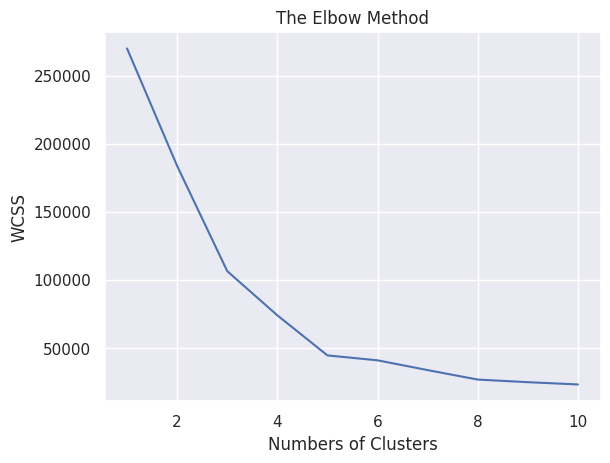

In [ ]:
from sklearn.cluster import KMeans
wcss = []                               # WCSS - ( Within-Cluster-Sum of Squares )
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init = 'k-means++',random_state = 42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11),wcss)
plt.title('The Elbow Method')
plt.xlabel('Numbers of Clusters')
plt.ylabel('WCSS')
plt.show()

#2. How do you choose 'K' (the number of clusters) based on this graph?
When this graph appears on your screen, it will resemble the elbow of a human hand.

* **Initial (K=1, 2):** The graph will drop very rapidly (because the WCSS value will decrease rapidly).
* **The Elbow Point:** There will be a point in the graph where the decline slows down significantly and the line becomes almost straight or flat.
* **Correct choice:** The number at which the elbow is formed will be the correct number of clusters (n_clusters). Typically, in real data, this point occurs at 3, 4, or 5.

**Note:-** In our data it is happening at 3 & 5 so first we take **n_clusters= 3**.

# Training the K-Means Model on Dataset

In [ ]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_kmeans =  kmeans.fit_predict(x)
y_kmeans

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1], dtype=int32)

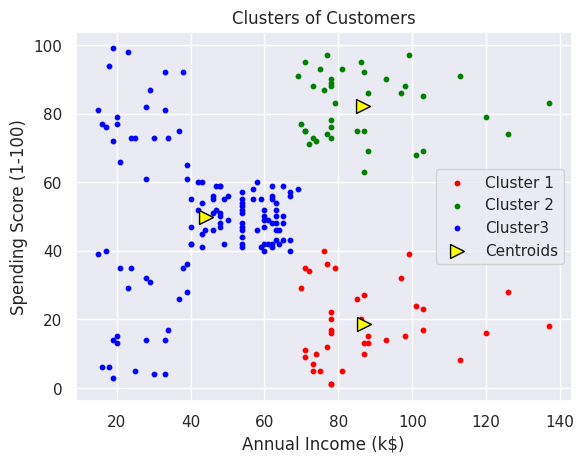

In [ ]:
# Visualization
colors = ['red','green','blue']
labels = ['Cluster 1','Cluster 2','Cluster3']
for i in range(3):
  plt.scatter(x[y_kmeans==i,0], x[y_kmeans==i,1], s=10, c=colors[i], label=labels[i])
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=100, c='yellow', marker='>', edgecolors='black', label='Centroids')

plt.title('Clusters of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()


`Mall_Customers.csv` is the data, in which we have features like **Annual Income** and **Spending Score**.

And there could be various types of customers on the behalf of these two features so **we shall continue with `K=5`** for getting best insights.

# For K= 5

In [ ]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans =  kmeans.fit_predict(x)

df['Cluster_K5'] = y_kmeans   # For adding 'Cluster_K5' column in Original dataframe
print(df.head())


   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster_K5  
0           4  
1           2  
2           4  
3           2  
4           4  


# Visualization the Clusters


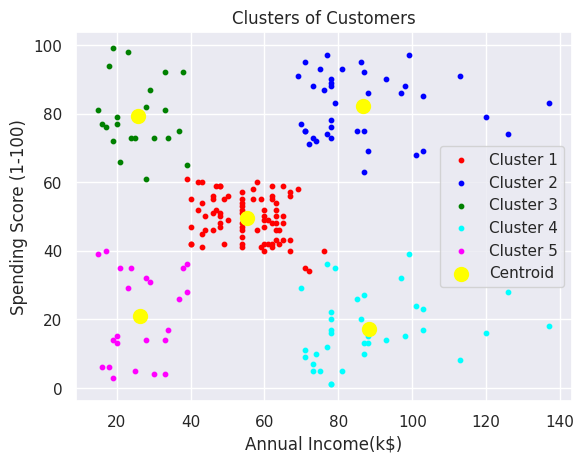

In [ ]:
plt.scatter(x[y_kmeans==0,0],x[y_kmeans==0,1], s=10, c='red', label= 'Cluster 1')
plt.scatter(x[y_kmeans==1,0],x[y_kmeans==1,1], s=10, c='blue', label= 'Cluster 2')
plt.scatter(x[y_kmeans==2,0],x[y_kmeans==2,1], s=10, c='green', label= 'Cluster 3')
plt.scatter(x[y_kmeans==3,0],x[y_kmeans==3,1], s=10, c='cyan', label='Cluster 4')
plt.scatter(x[y_kmeans==4,0],x[y_kmeans==4,1], s=10, c='magenta',label='Cluster 5')

plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=100, c='yellow', label='Centroid')
plt.title('Clusters of Customers')
plt.xlabel('Annual Income(k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

Or we can sort the code by For loop for this visulization -

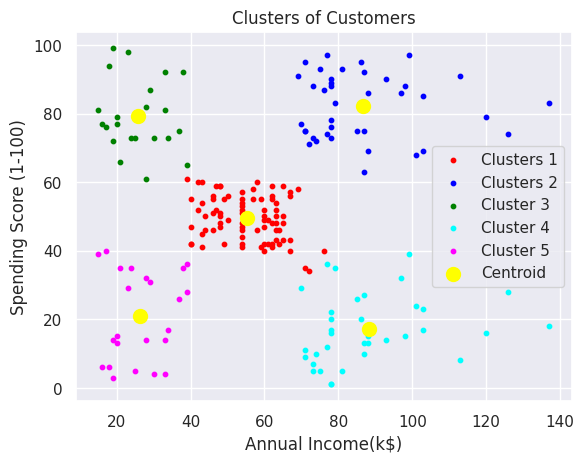

In [ ]:
colors = ['red','blue','green','cyan','magenta']
labels = ['Clusters 1', 'Clusters 2', 'Cluster 3', 'Cluster 4', 'Cluster 5']

for i in range(5):
  plt.scatter(x[y_kmeans==i,0],x[y_kmeans==i,1], s=10, c=colors[i], label=labels[i])
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=100, c='yellow', label='Centroid')

plt.title('Clusters of Customers')
plt.xlabel('Annual Income(k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

# Now next step is **Cluster Profiling (giving each group a name and identity)** and then **Creating a Business Strategy**.

In [ ]:
# Now groupby each cluster to get the average value of that. As we saved K=5 labels 'Cluster_K5' column, So -
cluster_profile = df.groupby('Cluster_K5')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
print(cluster_profile)

            Annual Income (k$)  Spending Score (1-100)
Cluster_K5                                            
0                    55.296296               49.518519
1                    86.538462               82.128205
2                    25.727273               79.363636
3                    88.200000               17.114286
4                    26.304348               20.913043


- **Cluster 0 (Standard):** Average income aur average spending wale log. Ye aapka base crowd hai.
- **Cluster 1 (Target/VIP):** High Income aur High Spending Score. Ye mall ke sabse zyada profitable customers hain.
- **Cluster 2 (Careless):** Low Income hai fir bhi Spending Score bohot high hai. Ye impulsive buyers hain.
- **Cluster 3 (Sensible):** High Income hai par Spending Score kam hai. Ye soch-samajh kar kharch karte hain.
- **Cluster 4 (Careful):** Low Income aur Low Spending Score. Ye log sirf zaroorat ka saaman lete hain.

---

# **2. Next Actionable Steps (Mall Ke Liye Strategy)**

Ab aapko in clusters ke hisab se marketing strategy design karni hai:

- **Target Group (High Income, High Spend):** Inhe naye premium brands, VIP lounge access, aur exclusive product launches ke alerts bhejo.
- **Sensible Group (High Income, Low Spend):** Inhe cash-back offers, high-quality durability features, aur value-for-money deals dikhao taaki ye kharch karein.
- **Careless Group (Low Income, High Spend):** Inhe sale, buy-1-get-1 offers, aur trendy/fast-fashion items target karo.